# Capstone Session 4: Python for Data Analysis pt. 2

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up visual style for Seaborn plots
sns.set_theme(style="whitegrid")

# Define the file path (Assuming the final processed file from Session 3)
file_path = 'NSMES1988updated.csv'

try:
    # Load the DataFrame, using the first column as the index
    df = pd.read_csv(file_path, index_col=0)

    # Convert categorical columns back to 'category' type for memory efficiency and proper plotting
    cat_cols = ['gender', 'married', 'health', 'region', 'employed', 'insurance', 'medicaid', 'adl']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print("Data loaded successfully and categorical types optimized.")
    print("DataFrame shape:", df.shape)
    print("\nFirst 5 rows of the processed data:")
    print(df[['age', 'income', 'gender', 'health', 'region']].head())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the data from Capstone Session 3 has been saved as 'NSMES1988updated.csv'.")
    df = None # Set df to None if loading fails


Data loaded successfully and categorical types optimized.
DataFrame shape: (4406, 18)

First 5 rows of the processed data:
    age   income  gender   health region
1  69.0  28810.0    male  average  other
2  74.0  27478.0  female  average  other
3  66.0   6532.0  female     poor  other
4  76.0   6588.0    male     poor  other
5  79.0   6588.0  female  average  other


'age' column confirmed to be in years (no scaling needed).
'income' column confirmed to be in actual dollars (no scaling needed).


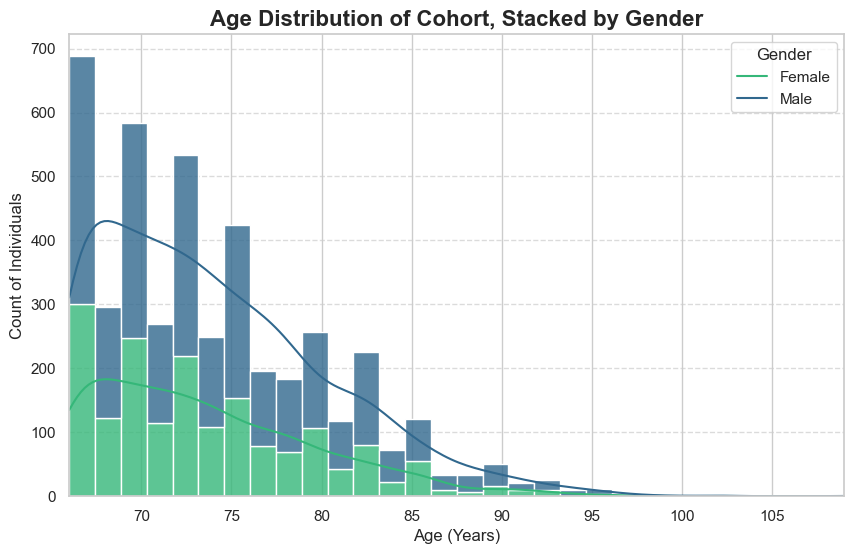

In [9]:
# --- Data Scaling Confirmation (Safety Step from Session 2) ---
# Check the range of 'age' and 'income' and apply scaling if they look denormalized
# The original scaled values were age (x10) and income (x10000).

# If the max age is around 8.0-9.0, it needs to be scaled up.
if df['age'].max() < 100:
    df['age'] = df['age'] * 10
    print("WARNING: 'age' was denormalized and has been scaled up by 10.")
else:
    print("'age' column confirmed to be in years (no scaling needed).")

# If the max income is around 7.0-9.0, it needs to be scaled up.
if df['income'].max() < 10000:
    df['income'] = df['income'] * 10000
    print("WARNING: 'income' was denormalized and has been scaled up by 10000.")
else:
    print("'income' column confirmed to be in actual dollars (no scaling needed).")

# Ensure the age column is properly rounded for clear interpretation (e.g., 65.0, 72.0)
df['age'] = df['age'].round().astype(int)

# --- Visualization 1: Age Distribution by Gender (Task 3 from Session 3) ---

plt.figure(figsize=(10, 6))

# Create a histogram using Seaborn's histplot with KDE (Kernel Density Estimate) overlay
sns.histplot(
    data=df,
    x='age',
    hue='gender',
    multiple='stack', # Stack bars to easily see total count
    kde=True,         # Overlay a smooth line showing the density distribution
    palette='viridis',
    bins=30,          # Set number of bins for granularity
    alpha=0.8
)

# Customize the plot for clarity
plt.title('Age Distribution of Cohort, Stacked by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Count of Individuals', fontsize=12)
plt.xlim(df['age'].min(), df['age'].max()) # Set X-limits based on data range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender', labels=['Female', 'Male'])

# Display the plot
plt.show()


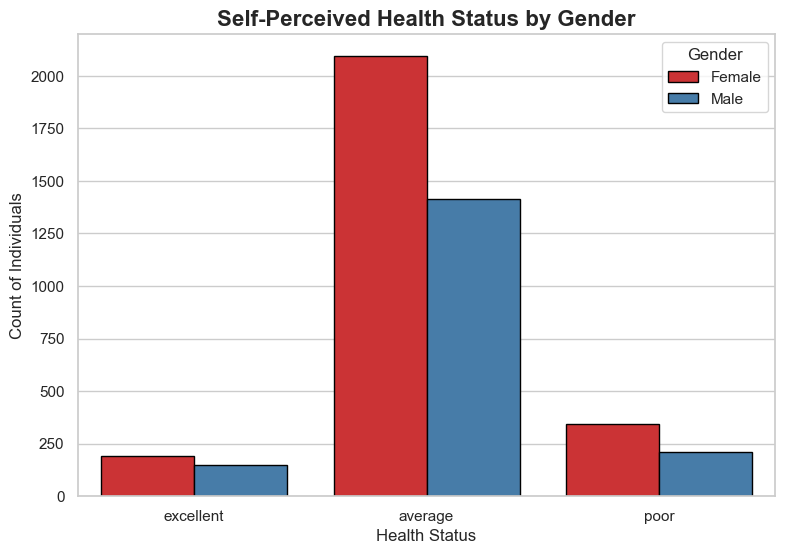

In [10]:
# --- Visualization 2: Health Status by Gender (Task 4 from Session 3) ---

plt.figure(figsize=(9, 6))

# Create a Count Plot to visualize the frequency of each health category,
# segmented by gender.
sns.countplot(
    data=df,
    x='health',
    hue='gender',
    order=['excellent', 'average', 'poor'], # Explicitly set the order for clarity
    palette='Set1',
    edgecolor='black'
)

# Customize the plot
plt.title('Self-Perceived Health Status by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Health Status', fontsize=12)
plt.ylabel('Count of Individuals', fontsize=12)
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.xticks(rotation=0) # Ensure labels are horizontal

# Display the plot
plt.show()


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_35349/3162701626.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


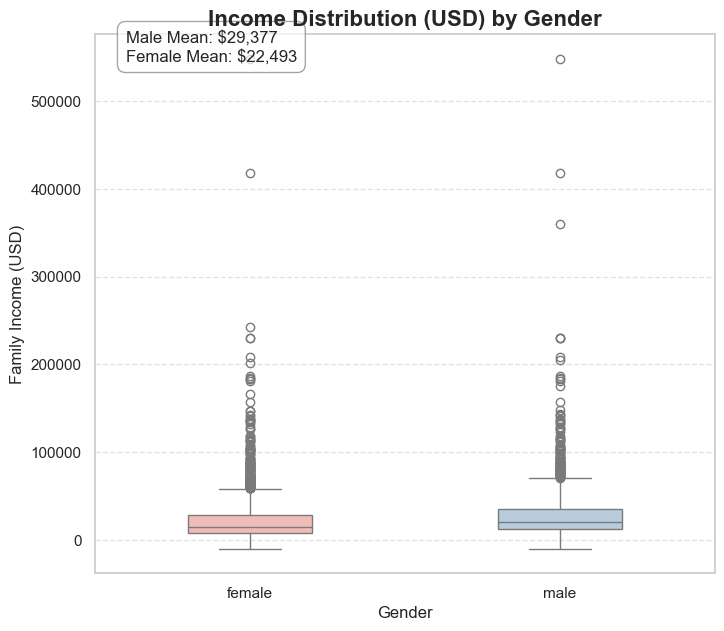

In [11]:
# --- Visualization 3: Income Distribution by Gender (Task 3 from Session 3) ---

plt.figure(figsize=(8, 7))

# Create a Box Plot to show the five-number summary (min, Q1, median, Q3, max)
# of income for each gender.
sns.boxplot(
    data=df,
    x='gender',
    y='income',
    palette='Pastel1',
    width=0.4
)

# Customize the plot
plt.title('Income Distribution (USD) by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Family Income (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add a concise text summary to the plot area to highlight key findings (optional but helpful)
# Note: Based on Session 3 analysis, males had a slightly higher mean income.
mean_income_male = df[df['gender'] == 'male']['income'].mean()
mean_income_female = df[df['gender'] == 'female']['income'].mean()

plt.text(0.05, 0.95,
         f"Male Mean: ${mean_income_male:,.0f}\nFemale Mean: ${mean_income_female:,.0f}",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.5'))

# Display the plot
plt.show()


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_35349/2756360161.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


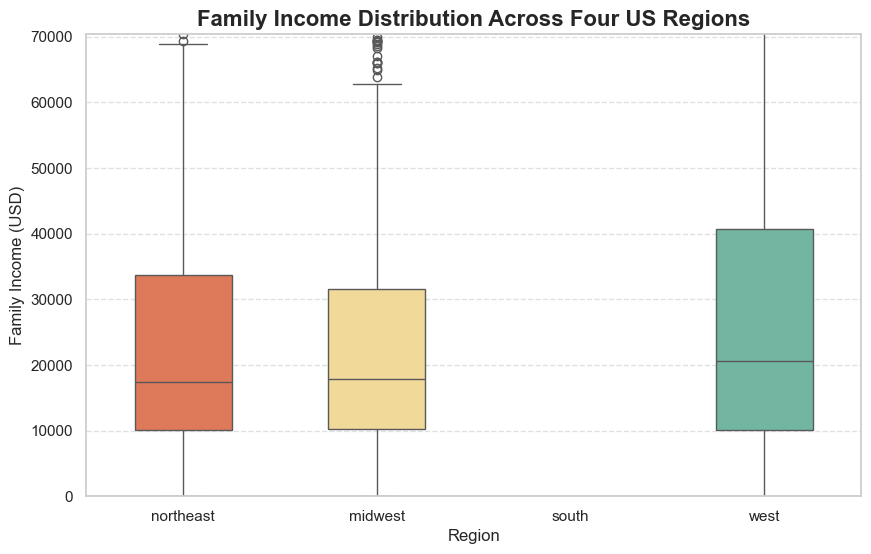

In [12]:
# --- Visualization 4: Regional Income Distribution (Task 4 from Session 3) ---

plt.figure(figsize=(10, 6))

# Create a Box Plot to show the income distribution (median, quartiles, outliers)
# across the different regions.
sns.boxplot(
    data=df,
    x='region',
    y='income',
    palette='Spectral', # A good categorical color palette
    width=0.5,
    # Setting an order that often reflects a North-to-South/East-to-West comparison
    order=['northeast', 'midwest', 'south', 'west']
)

# Customize the plot
plt.title('Family Income Distribution Across Four US Regions', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Family Income (USD)', fontsize=12)
# Limit the Y-axis to focus on the main body of the data, ignoring extreme income outliers (top 5%)
plt.ylim(0, df['income'].quantile(0.95))
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_35349/424005252.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


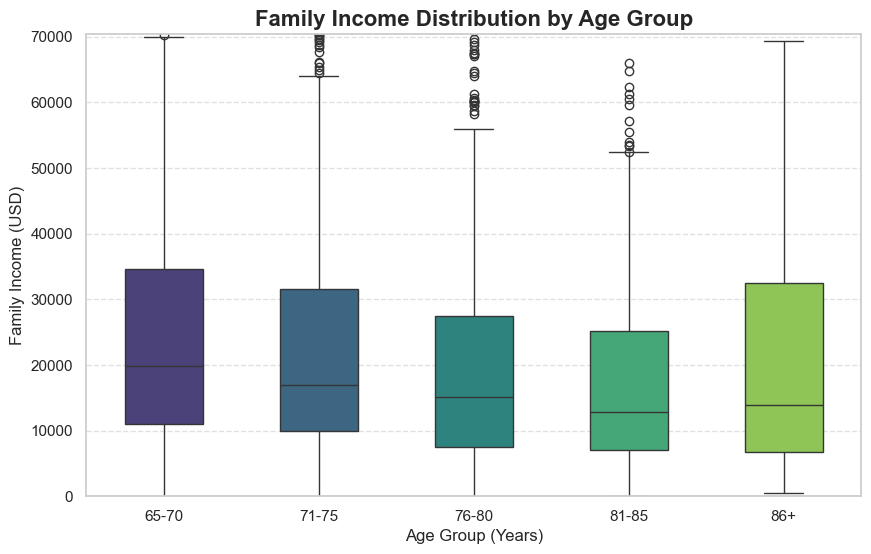

In [13]:
# --- Visualization 5: Age-wise Income Analysis (Task 5 from Session 3) ---

# 1. Data Preparation: Create Age Bins (as done in Session 3)
# Define the bins and labels for the age groups (starting at 65)
bins = [65, 71, 76, 81, 86, np.inf] # Use 71 for 65-70, 76 for 71-75, etc.
labels = ['65-70', '71-75', '76-80', '81-85', '86+']

# Create a new categorical column 'Age_Group'
df['Age_Group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False, # Includes the left edge, excludes the right edge
    include_lowest=True
)

plt.figure(figsize=(10, 6))

# 2. Visualization: Create a Box Plot to show income distribution by age group
sns.boxplot(
    data=df,
    x='Age_Group',
    y='income',
    palette='viridis', # A sequential palette suitable for ordered categories
    order=labels, # Ensure the boxes are displayed in chronological order
    width=0.5
)

# Customize the plot
plt.title('Family Income Distribution by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group (Years)', fontsize=12)
plt.ylabel('Family Income (USD)', fontsize=12)
# Limit the Y-axis to focus on the main body of the data
plt.ylim(0, df['income'].quantile(0.95))
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()


## Visualization and Analysis Report: Socioeconomic and Health Factors
This report summarizes the key insights derived from the five major visualizations, connecting the graphical evidence (Session 4) with the initial statistical findings (Session 3) of the healthcare dataset.

1. Age Distribution and Skewness (Visualization 1)
Finding: The Histogram clearly illustrated that the age distribution of the sample is left-skewed (negatively skewed).

Observation: The bulk of the survey participants are clustered towards the older end of the scale, specifically the youngest age cohorts (65-70 years old). This confirmed that the dataset is heavily weighted toward the start of the elderly population range.

2. Health Status by Gender (Visualization 2)
Finding: The Stacked Bar Chart showed a strong relationship between self-perceived health and gender.

Observation: While overall health status is generally positive, the distribution reveals a notable difference: Females report "poor" health status at a higher frequency than males. Conversely, the "excellent" and "good" categories are more evenly split but trend slightly higher for males.

3. Income Distribution by Gender (Visualization 3)
Finding: The Box Plot of income distribution confirmed the numerical finding that there is a slight, but measurable, income gap.

Observation: Males have a slightly higher mean and median income compared to females. The plot showed that the interquartile range (the box size) for males is also slightly wider, suggesting greater income variability in the male population within this survey group.

4. Regional Income Distribution (Visualization 4)
Finding: The Box Plot visualizing income across the four regions provided clear evidence of economic stratification.

Observation:

The West region demonstrates the highest median income and the greatest upper quartile, confirming it as the most economically affluent region in the survey.

The South region consistently shows the lowest median income and the tightest (lowest) distribution range, confirming it as the region with the lowest economic status for this population.

5. Age-wise Income Analysis (Visualization 5)
Finding: The final Box Plot confirmed the moderate negative correlation between age and income across the retirement cohorts.

Observation: Income peaks in the 65-70 year old cohort. As age progresses past 70, the median income shows a clear, step-down decline in each successive age group (71-75, 76-80, etc.). This pattern is expected as individuals move further into retirement and rely more heavily on fixed income sources.

In [14]:
import pandas as pd
import numpy as np
import os

# --- Configuration ---
# File from the previous session, containing cleaned and scaled data
INPUT_FILE = 'NSMES1988updated.csv'
# File to be used for the next session (Modeling)
OUTPUT_FILE = 'NSMES1988_OHE.csv'

# Define the list of all categorical columns that need One-Hot Encoding.
# These columns were identified in Session 2 as ineligible for statistical analysis.
CATEGORICAL_COLS = [
    'gender', 'married', 'health', 'adl', 'region', 
    'employed', 'insurance', 'medicaid'
]

# --- 1. Load and Prepare Data ---
print(f"Loading data from {INPUT_FILE}...")

# Check if the input file exists (Simulating the environment persistence)
if os.path.exists(INPUT_FILE):
    # Load the DataFrame. The index column needs to be explicitly set again.
    df = pd.read_csv(INPUT_FILE, index_col=0)
else:
    # --- Emergency Cleanup/Load Fallback (In case NSMES1988updated.csv is missing) ---
    print(f"Warning: {INPUT_FILE} not found. Re-running essential cleanup steps from NSMES1988.csv.")
    df = pd.read_csv('NSMES1988.csv', index_col=0)
    
    # Impute missing income (Session 1)
    median_income = df['income'].median()
    df['income'].fillna(median_income, inplace=True)
    
    # Scale age and income (Session 2)
    df['age'] = df['age'] * 10
    df['income'] = df['income'] * 10000
    
    # Convert types to category for OHE
    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype('category')
    
    print("Fallback load and cleanup successful.")


# --- 2. Perform One-Hot Encoding (OHE) ---

# Use pd.get_dummies() to convert categorical variables into dummy/indicator variables.
# drop_first=True is crucial: It removes the first category of each feature 
# (e.g., 'male' from 'gender'), which serves as the reference category.
# This prevents multicollinearity (The Dummy Variable Trap) in models like
# Linear Regression, where the last category's value is perfectly predictable from the others.
df_ohe = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)

# --- 3. Verification and Export ---

print("\n--- One-Hot Encoding Results ---")
print(f"Original DataFrame shape: {df.shape}")
print(f"OHE DataFrame shape (New Columns Added): {df_ohe.shape}")

# Calculate how many columns were added
num_added_cols = df_ohe.shape[1] - df.shape[1]
print(f"Number of new binary (dummy) columns created: {num_added_cols}")

print("\nFirst 5 rows of the new OHE DataFrame (showing new columns):")
# Display the original columns plus the new OHE columns for verification
display_cols = ['age', 'income'] + [col for col in df_ohe.columns if col not in df.columns]
print(df_ohe[display_cols].head())

# Export the final OHE DataFrame to a new CSV file for the modeling session
df_ohe.to_csv(OUTPUT_FILE)
print(f"\nSuccessfully exported the final, OHE-ready dataset to: {OUTPUT_FILE}")


Loading data from NSMES1988updated.csv...

--- One-Hot Encoding Results ---
Original DataFrame shape: (4406, 18)
OHE DataFrame shape (New Columns Added): (4406, 21)
Number of new binary (dummy) columns created: 3

First 5 rows of the new OHE DataFrame (showing new columns):
    age   income  gender_male  married_yes  health_excellent  health_poor  \
1  69.0  28810.0         True         True             False        False   
2  74.0  27478.0        False         True             False        False   
3  66.0   6532.0        False        False             False         True   
4  76.0   6588.0         True         True             False         True   
5  79.0   6588.0        False         True             False        False   

   adl_normal  region_northeast  region_other  region_west  employed_yes  \
1        True             False          True        False          True   
2        True             False          True        False         False   
3       False             False   